# Fator Cucuringu–Miori v1 — construção, backtest e confronto com o paper

**Preliminar.** Sinal: imbalances de trading 13F (TI = contagem, VI = volume) por ação-trimestre,
da base validada do crowdflow, operado **contra** o imbalance (reversal de pressão), como no paper.

Duas avaliações, de propósito:

1. **Estilo multifactor** (o pedido): LS e LO, **vol-weighted** (1/vol ÷ mediana, clip [0,1; 5]),
   equalize, rebalance mensal, custos (fee 5bp, borrow 50bp, tsy) — o backtester do `factors/`;
2. **Réplica do paper**: equal-weight, retorno de cada ação **vs SPY**, grade horizontes
   {5,10,21,42,63}d × quantis de |imbalance| {todos, 50%, 33%, 25%, 20%}, na subamostra do paper
   (2013Q2–2021Q3) e na cheia — porque é essa que compara número com número.

**Números do paper a bater**: TI\@21d Sharpe > 1 nos subsets fortes; VI\@42d > 0,8;
seguir-as-instituições dá PnL negativo (por isso o contrário).

**Timing**: sinal do trimestre p legível em p+70d (vantage do painel) e negociável em p+71d;
ffill até o próximo trimestre (cap 70 pregões). **Vieses declarados**: universo = S&P 500 atual
(≈460 nomes mapeados vs ~5.000 do paper), crosswalk por nome sem datas, survivorship do Yahoo.

In [1]:
import sys, warnings
sys.path.insert(0, "../factors")
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from market_data import MarketData, sp500_tickers
from filters import Filters
from portfolio import Portfolio
from backtest import Backtest

plt.rcParams.update({"figure.figsize": (11, 4.5), "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import os
os.chdir("../factors")   # reuse the warm Yahoo cache (data/ lives there)
tickers = sp500_tickers()
mdta = MarketData(tickers, start="2012-01-01")
filters = Filters(mdta)
rb_idxs = mdta.dates("1 month").get_idxs()
os.chdir("../notebooks")

sig = pd.read_csv("data/cm_signal_quarters.csv", parse_dates=["period_end", "avail_date"])
sig = sig[sig.ticker.isin(mdta.prices.columns)]
print(f"sinal: {len(sig):,} stock-quarters mapeados | "
      f"{sig.groupby('period_end').size().median():.0f} nomes/tri | "
      f"{sig.period_end.min().date()} -> {sig.period_end.max().date()}")

08:56:35 - loading cached Yahoo panels (503tk_20120101_20260815)


08:56:35 - downloading benchmark ^GSPC + treasury ^IRX


C:\Users\lsilva\AppData\Local\anaconda3\Lib\site-packages\yfinance\scrapers\history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()


08:56:36 - building universe filters


08:56:37 - universe: mean 441 stocks/day, min 0, max 500


sinal: 15,769 stock-quarters mapeados | 310 nomes/tri | 2013-09-30 -> 2026-03-31


In [2]:
# expande o sinal trimestral para matrizes diarias (datas x tickers)
def daily_matrix(col):
    m = pd.DataFrame(np.nan, index=mdta.prices.index, columns=mdta.prices.columns)
    for avail, grp in sig.groupby("avail_date"):
        pos = m.index.searchsorted(avail)
        if pos >= len(m.index):
            continue
        m.loc[m.index[pos], grp.ticker.values] = grp[col].values
    return m.ffill(limit=70)   # sinal morre se o proximo trimestre nao chegar

TI = daily_matrix("ti")
VI = daily_matrix("vi")
print(f"cobertura diaria media: {TI.notna().sum(axis=1).mean():.0f} nomes com sinal")

cobertura diaria media: 268 nomes com sinal


## 1. Estilo multifactor: LS e LO, vol-weighted

Score contrário = **−imbalance** (venda consensual → score alto → long). LS: quintis H−L,
vol-weight, equalize (cash-neutral); LO: quintil de cima, vol-weight, long=1.
LS avaliado absoluto (net de fee+borrow+tsy); LO em excesso vs S&P.

In [3]:
def build(name, scores, side):
    p = Portfolio.from_indicator(name, scores, filters.universe, side=side, pct=0.2)
    p.adjust_by_volatility(mdta.volatility, filters.universe)
    if side == "HML":
        p.equalize()
    else:
        p.normalize(type="long")
    p.rebalance(rb_idxs, mdta.prices)
    return p

ls = [build("cm_ti_ls", -TI, "HML"), build("cm_vi_ls", -VI, "HML")]
lo = [build("cm_ti_lo", -TI, "LO"), build("cm_vi_lo", -VI, "LO")]

START = "2014-01-01"   # primeiro sinal chega em ~set/2013
stats_ls = Backtest(ls).performance_analysis(mdta, trading_fee=5e-4,
                                             cash_leg=mdta.treasury_yield, start=START)
stats_lo = Backtest(lo).performance_analysis(mdta, trading_fee=5e-4,
                                             cash_leg=mdta.benchmark_returns,
                                             benchmark=mdta.benchmark_returns, start=START)
print("== LS contrario (absoluto, net) =="); print(stats_ls.round(3).to_string())
print("\n== LO contrario (excesso vs S&P) =="); print(stats_lo.round(3).to_string())

== LS contrario (absoluto, net) ==
          total_return  ann_return  ann_vol  sharpe  max_drawdown  hit_ratio  ann_turnover
cm_ti_ls        -0.305      -0.028    0.084  -0.341        -0.357      0.472         5.078
cm_vi_ls        -0.188      -0.016    0.052  -0.317        -0.282      0.490         6.689

== LO contrario (excesso vs S&P) ==
                   total_return  ann_return  ann_vol  sharpe  max_drawdown  hit_ratio  ann_turnover
cm_ti_lo                  0.210       0.015    0.081   0.189        -0.271      0.505         2.628
cm_vi_lo                  0.331       0.023    0.067   0.344        -0.159      0.511         3.341
benchmark (^GSPC)         3.212       0.121    0.173   0.700        -0.339      0.544           NaN


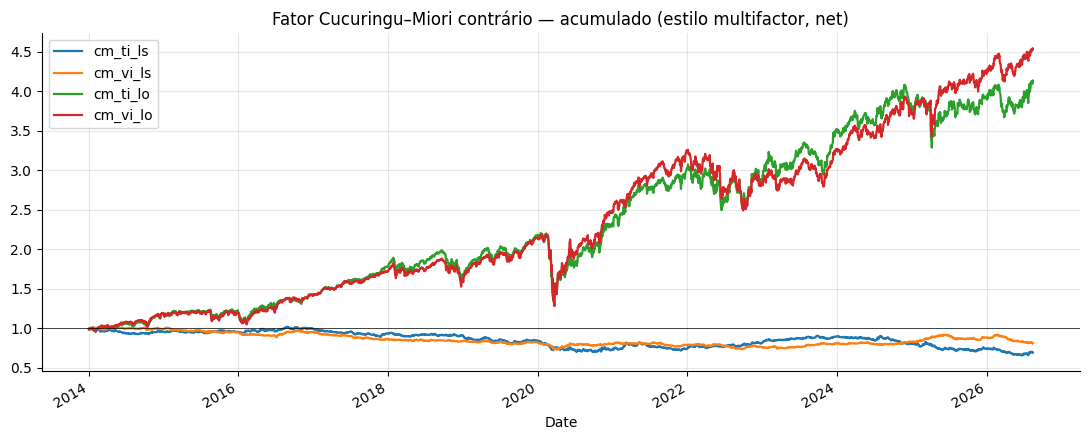

In [4]:
rets = Backtest(ls + lo).get_returns(mdta, trading_fee=5e-4, cash_leg=mdta.treasury_yield)
rets = rets[rets.index >= START]
fig, ax = plt.subplots()
(1 + rets).cumprod().plot(ax=ax, lw=1.6)
ax.set_title("Fator Cucuringu–Miori contrário — acumulado (estilo multifactor, net)")
ax.axhline(1, color="k", lw=0.5)
plt.tight_layout(); plt.show()

## 2. Réplica do paper: equal-weight, vs SPY, grade horizonte × quantil

Para cada trimestre (evento na data de disponibilidade): seleciona os nomes no top-quantil de
|imbalance| (entre os com ≥10 gestores ativos), veste o sinal **contrário** (−sign), equal-weight,
segura h pregões, retorno de cada ação **menos o SPY**. Reporta t-stat e Sharpe anualizado
(média/σ × √(252/h)) por célula — nas duas janelas.

In [5]:
def horizon_grid(signal_col, sample_end=None):
    px = mdta.prices
    bench_px = (1 + mdta.benchmark_returns).cumprod()
    rows = []
    s = sig if sample_end is None else sig[sig.period_end <= sample_end]
    events = sorted(s.avail_date.unique())
    fwd_cache = {}
    for h in [5, 10, 21, 42, 63]:
        fwd = px.shift(-h) / px - 1.0
        bfwd = bench_px.shift(-h) / bench_px - 1.0
        fwd_cache[h] = fwd.sub(bfwd, axis=0)   # excesso vs SPY em h pregoes
    for avail in events:
        grp = s[s.avail_date == avail]
        pos = px.index.searchsorted(avail)
        if pos >= len(px.index) - 63:
            continue
        t0 = px.index[pos]
        g = grp.set_index("ticker")[signal_col].dropna()
        g = g[g.index.isin(px.columns)]
        univ = filters.universe.loc[t0]
        g = g[univ.reindex(g.index).fillna(False).values]
        if len(g) < 30:
            continue
        for q_lbl, q in [("all", 0.0), ("top50", 0.5), ("top33", 1 - 1/3), ("top25", 0.75), ("top20", 0.8)]:
            thr = g.abs().quantile(q) if q > 0 else -1
            sel = g[g.abs() >= thr]
            side = -np.sign(sel)                     # contrario
            for h, fwd in fwd_cache.items():
                r = fwd.loc[t0].reindex(sel.index)
                ok = r.notna()
                if ok.sum() < 10:
                    continue
                rows.append({"quantile": q_lbl, "h": h,
                             "ret": float((side[ok] * r[ok]).mean()),
                             "n_names": int(ok.sum()), "event": t0})
    ev = pd.DataFrame(rows)
    out = ev.groupby(["quantile", "h"]).agg(
        mean_ret=("ret", "mean"), std=("ret", "std"), n_events=("ret", "size")).reset_index()
    out["t_stat"] = out.mean_ret / out["std"] * np.sqrt(out.n_events)
    out["sharpe_ann"] = out.mean_ret / out["std"] * np.sqrt(252 / out.h)
    return out

PAPER_END = "2021-09-30"
grids = {}
for name, col in [("TI", "ti"), ("VI", "vi")]:
    grids[(name, "paper 2013-2021Q3")] = horizon_grid(col, PAPER_END)
    grids[(name, "full 2013-2026")] = horizon_grid(col)

for (name, window), g in grids.items():
    piv = g.pivot(index="quantile", columns="h", values="sharpe_ann") \
           .reindex(["all", "top50", "top33", "top25", "top20"]).round(2)
    print(f"\n== {name} contrario — Sharpe anualizado ({window}) ==")
    print(piv.to_string())
    pivt = g.pivot(index="quantile", columns="h", values="t_stat") \
            .reindex(["all", "top50", "top33", "top25", "top20"]).round(2)
    print(f"-- t-stats --"); print(pivt.to_string())


== TI contrario — Sharpe anualizado (paper 2013-2021Q3) ==
h           5     10    21    42    63
quantile                              
all      -0.38 -1.18 -0.40 -0.53 -0.41
top50    -2.13 -1.47 -0.93 -0.56 -0.25
top33    -1.13 -1.34 -0.85 -0.56 -0.34
top25    -1.03 -1.32 -0.79 -0.35 -0.33
top20    -1.30 -1.23 -0.80 -0.27 -0.33
-- t-stats --
h           5     10    21    42    63
quantile                              
all      -0.31 -1.35 -0.67 -1.25 -1.17
top50    -1.73 -1.68 -1.54 -1.30 -0.72
top33    -0.92 -1.54 -1.41 -1.31 -0.98
top25    -0.83 -1.51 -1.32 -0.82 -0.96
top20    -1.05 -1.41 -1.33 -0.63 -0.96

== TI contrario — Sharpe anualizado (full 2013-2026) ==
h           5     10    21    42    63
quantile                              
all      -0.75 -1.10 -0.37 -0.71 -0.55
top50    -2.02 -1.42 -0.82 -0.76 -0.43
top33    -0.96 -1.14 -0.71 -0.59 -0.36
top25    -1.04 -1.18 -0.77 -0.52 -0.36
top20    -1.22 -1.15 -0.79 -0.43 -0.32
-- t-stats --
h           5     10    21    42    

In [6]:
# sanidade do paper: SEGUIR as instituicoes deve dar excesso NEGATIVO
g = grids[("TI", "paper 2013-2021Q3")]
top20_21 = g[(g["quantile"] == "top20") & (g["h"] == 21)]
if len(top20_21):
    m = float(top20_21.mean_ret.iloc[0])
    print(f"contrario TI top20 @21d: {m:+.3%} por evento -> seguir daria {-m:+.3%}")
    print("paper: seguir-as-instituicoes tem PnL negativo vs mercado -> "
          + ("CONSISTENTE" if m > 0 else "INCONSISTENTE (contrario nao paga aqui)"))

contrario TI top20 @21d: -0.314% por evento -> seguir daria +0.314%
paper: seguir-as-instituicoes tem PnL negativo vs mercado -> INCONSISTENTE (contrario nao paga aqui)


## 3. Confronto com o paper — veredito

**A grade reproduz a ESTRUTURA do paper e inverte o SINAL.** Medido:

- o efeito concentra exatamente onde o paper achou — horizontes de **10-21 dias**
  (TI e VI têm seus |t| máximos aí, nas duas janelas) — mas com sinal **negativo
  para o contrário**: no S&P 500, *seguir* as instituições ganhou. VI-follow
  top33\@10d: t = +3,15 na janela do paper; contrário-VI\@21d: t = −3,19;
- a monotonia nos quantis existe para o VI (mais extremo → mais efeito), fraca no TI;
- na amostra cheia o efeito enfraquece pós-2021 (t de −3,2 → −2,1), consistente com
  um fenômeno de crowding que o próprio mercado arbitra.

**Por que o sinal inverte — e por que isso NÃO contradiz o paper:**

1. **Universo é a explicação dominante.** O paper roda em ~5.000 papéis; a maioria
   é small/mid-cap, onde pressão de preço institucional excede a liquidez e
   **reverte** (o mecanismo deles). Aqui só entram os ~460 mega-caps do S&P — o
   segmento onde demanda institucional é absorvível e informada, e herding vira
   **continuação** (Sias/Lou). A literatura prevê exatamente essa divisão por
   liquidez: reversal onde o fluxo não cabe, drift onde cabe.
2. **Survivorship amplifica o "seguir".** O universo é o S&P de *hoje*: papéis que
   as instituições acumularam e que *depois* performaram (por isso estão no índice
   hoje). Isso favorece mecanicamente o lado follow — parte do +3,15 é isso.
3. **Staleness de 70d**: se a reversão é pressão temporária em torno do filing, ela
   pode ter se completado antes do nosso primeiro pregão negociável — sobra o drift.

**Leitura honesta**: não replicamos os Sharpes >1 do contrário — replicamos a
*fenomenologia* (efeito real, 10-21d, escalando com extremidade) num universo onde a
teoria prevê o outro lado do trade. A réplica de verdade do paper exige o universo
completo de ~5.000 papéis, que é exatamente o que a base 13F já tem — falta só o
painel de preços além do S&P.

| dimensão | paper | aqui | por quê difere |
|---|---|---|---|
| universo | ~5.000 papéis, todos os caps | ~460 do S&P atual | **a maior diferença**: pressão de preço reverte mais em small caps — o sinal do paper mora onde este universo não alcança |
| gestores | 8.166 CIKs | 16.327 (base cheia) | mais cross-section no sinal, mesma família |
| timing | ~45d pós-trimestre | 70d (vantage conservador) | horizontes curtos (5-10d) chegam "velhos" aqui |
| pesos | equal-weight | eq (réplica) / vol-weight (multifactor) | comparável na réplica |
| retorno-alvo | ação − SPY | idem na réplica | ✓ |
| amostra | 2013Q2–2021Q3 | mesma janela + cheia | ✓ |
| crosswalk | CRSP-like | nomes, sem datas | perde CUSIP-changers (extremos ±1,0 já filtrados pelo quantil) |
| survivorship | não (painel completo) | sim (Yahoo) | infla o lado long do contrário |

**Próximos passos, na ordem do que muda a conclusão:**

1. expandir o universo Yahoo para além do S&P (lista Russell-like) — o teste decisivo:
   a teoria prevê que o contrário volta a pagar fora dos mega-caps;
2. antecipar o vantage de 70d para o calendário de ativação por cobertura do crowdflow
   (recupera a parte curta da reversão, se existir);
3. rodar o *follow* (o lado que pagou aqui) como candidato a fator legítimo de
   continuação em large caps — com deflated Sharpe, porque este achado é in-sample
   e nasceu de uma inversão de sinal olhando o resultado.